### Entropy Estimate: Gaussian Mixture Model

We learn a flow map from a simple **base** distribution to a more complex **target** in 40-dimensions:

- **Base** `p_0`: a single unit Gaussian, `N(0, I)` (unit variance, zero covariance).
- **Target** `p_1`: a 16-center Gaussian mixture model with randomized mean and covariances.

The `EESI` model trains a drift field `b(t, x)` and score field `s(t, x)` along the stochastic interpolant

$$x_t = \alpha(t)\,x_0 + \beta(t)\,x_1 + \gamma(t)\,z,\qquad z\sim N(0, I),$$

then estimates the entropy difference using a variety of strategies:
- integrate the learned probability-flow ODE from `t=0` (base) to `t=1` (target), acculumating entropy as either `b * s` or `div(b)` along the paths. 
- directly sample the interpolant from the data, taking the average of `b * s`, `b * z / gamma`, or `div(b)`


In [3]:
# --- imports & environment ---
import sys
import pathlib

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal


%matplotlib inline

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi import EESI, TimeMLP, GaussianMixture, CHECKPOINTS_DIR, DATA_DIR
from eesi.systems.gmm.train import train # training script

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Base and target distributions

The base is standard normal, `N(0, I)`. The target is a 16-component Gaussian
mixture built from `eesi.systems.gmm.data.GaussianMixture`, whose means are drawn once from a fixed `seed` and then held constant. The covariance matrix is diagonal with small constant values.

In [4]:
d = 40

# --- base: single 40-D Gaussian, unit variance, zero covariance ---
base = MultivariateNormal(torch.zeros(d, device=device), torch.eye(d, device=device))

# --- target: 16-center Gaussian mixture from eesi.systems.gmm.data.GaussianMixture ---
# Same target used in the FEAT paper
target = GaussianMixture(dim=d,n_mixes=16,loc_scaling=2,
                            log_var_scaling=-3,seed=10,device=device)



### 2. Model Loading

`EESI` wraps two `TimeMLP` fields: the velocity `net_b` and the score `net_s`.

- `path="linear"` uses the simple linear interpolant `x_t = (1 - t) * x_0 + t * x_1`.
- `gamma="sqrt"` adds the latent-noise schedule `gamma(t) = gamma_scale * sqrt(t(1-t))`, and the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate).


In [5]:
net_b = TimeMLP(d=d, hidden=512, n_layers=4, activation="silu")
net_s = TimeMLP(d=d, hidden=3072, n_layers=2, activation="silu")

model = EESI(net_b, net_s, d=d,
            path="linear", gamma="sqrt", gamma_scale=0.2
            ).to(device)

# load the trained models
model.net_b.load_state_dict(torch.load(CHECKPOINTS_DIR / 'gmm' / 'gmm_b.pth'))
model.net_s.load_state_dict(torch.load(CHECKPOINTS_DIR / 'gmm' / 'gmm_s.pth'))

<All keys matched successfully>

### 3. Training Logs

Loading the history logs from the training run(s), smoothing them, and plotting to examine convergence.

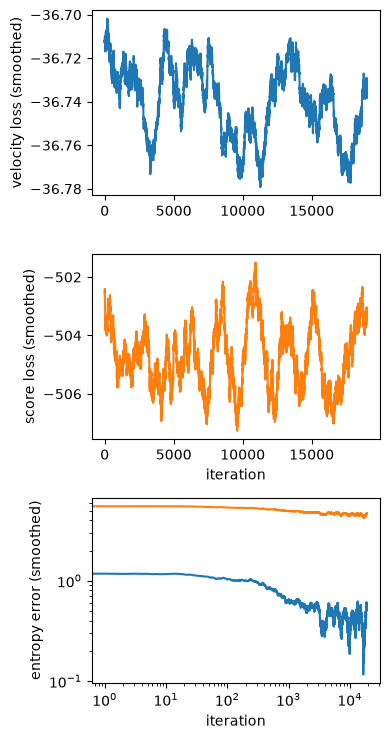

In [4]:
# Training curves (smoothed).
def smooth(v, k=1000):
    v = np.asarray(v)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

hist_b, hist_s, hist_S_dot, hist_S_zdot = np.load("./gmm_hist.npy").T

fig, ax = plt.subplots(3,1,sharex=False,figsize=(4,7.5))
ax[0].plot(smooth(hist_b),'-C0')
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s),'-C1')
ax[1].set_xlabel("iteration") 
ax[1].set_ylabel("score loss (smoothed)")

# target value (see cell below)
s_target = -61.443-56.7575
ax[2].plot(smooth(hist_S_zdot)-s_target,'-')
ax[2].plot(smooth(hist_S_dot)-s_target,'-')
ax[2].set_yscale('log')
ax[2].set_xscale('log')
ax[2].set_xlabel("iteration") 
ax[2].set_ylabel("entropy error (smoothed)")

plt.tight_layout()
plt.show()

### 4. Sampling

Map base samples to the target by integrating the ODE. `model.sample` with the diffusion coefficient `eps=0.0` integrates the probability-flow ODE `dx/dt = b(t, x)` with Heun's method. Setting `eps > 0.0` would integrates an SDE with the Euler–Maruyama scheme, which needs both the velocity `b` and score `s`.

Since we know the target distribution, we can (roughly) assess the quality of the samples and the anticipated entropy change by calculating the log probability.

In [7]:
# Draw base samples and push them through to the target
torch.manual_seed(18)
x0 = base.sample((20000,))
x1 = target.sample((20000,))
gen_ode = model.sample(x0, n_steps=50)            # probability-flow ODE

# How well do generated samples match the target? (mean log-density)
ref = target.log_prob(x1).mean()
base_ref = base.log_prob(x0).mean()
print(f"mean target log-prob - true target    : {ref:+.3f}")
print(f"mean target log-prob - sampled target : {target.log_prob(gen_ode).mean():+.3f}")
print(f"mean base   log-prob - true base      : {base_ref:+.3f}")
print(f"estimated entropy change : {-ref + base_ref:+.3f}")

# predicted change in entropy based on log likelihood from direct sampling of the target
delta_pred = -ref + base_ref
delta_pred = delta_pred.cpu().numpy()


mean target log-prob - true target    : +61.401
mean target log-prob - sampled target : +54.509
mean base   log-prob - true base      : -56.810
estimated entropy change : -118.210


Now we'll establish a more accurate reference for the target distribution entropy by lots of sampling.

In [8]:
import gc
gc.collect()
torch.cuda.empty_cache()

def strap(data,n_straps):
    data_size = len(data)
    means = np.zeros(n_straps)
    rng = np.random.default_rng()
    for i in range(n_straps):
        means[i] = np.mean(rng.choice(data, 
                                    size=data_size, 
                                    replace=True, 
                                    shuffle=True))
    return means.mean(), 1.96*means.std()

# repeat a few times to avoid OOMs while still getting lots of data
x1 = target.sample((250000,))
data = target.log_prob(x1).cpu()

for _ in range(7):
    x1 = target.sample((250000,))
    data2 = target.log_prob(x1).cpu()
    data = torch.concat((data,data2))

mean,err = strap(data,10000)
# difference with the analytical result for the base distribution
print(-56.743-mean) 
print(err)

# clear the cache so we don't OOM later on
import gc
gc.collect()
torch.cuda.empty_cache()

-118.19202346839904
0.0061750910207768375


### 5. Entropy along the paths

We track entropy accumulation during sample generation either by calculating the divergence of the velocity field `entropy="div"` or by taking the inner (dot) product of the velocity and score fields, `entropy="dot"`.

In [9]:
# Trace the running entropy change along many ODE paths.
torch.manual_seed(100)
batch = 20000
x0 = base.sample((batch,))

# first sample using the dot product formula
traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='dot', return_traj=True)
ts_c = ts.cpu().numpy()
ent_c_dot = ent_traj.cpu().numpy()

# for plotting later
dot_mean = ent_c_dot.mean(axis=1)
dot_std = ent_c_dot.std(axis=1)



# now with the divergence formula
traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='div', return_traj=True)
ent_c_div = ent_traj.cpu().numpy()

# for plotting later
div_mean = ent_c_div.mean(axis=1)
div_std = ent_c_div.std(axis=1)


In [10]:
mean_dot,err_dot = strap(ent_c_dot[-1],10000)
mean_div,err_div = strap(ent_c_div[-1],10000)

print(f"observed entropy change        : {delta_pred:+.3f}")
print(f"estimated entropy change (dot) : {mean_dot:+.3f} +/- {err_dot:.3f}")
print(f"estimated entropy change (div) : {mean_div:+.3f} +/- {err_div:.3f}")


observed entropy change        : -118.210
estimated entropy change (dot) : -114.717 +/- 0.382
estimated entropy change (div) : -117.698 +/- 0.030


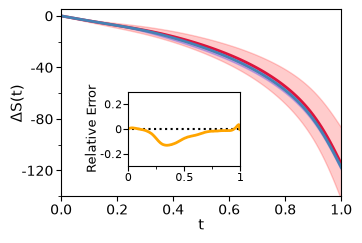

In [12]:
fig, ax = plt.subplots(figsize=(3.375, 2.25))
ax.plot(ts_c, dot_mean, c="crimson", lw=2, label="Dot Product")
ax.fill_between(ts_c, dot_mean - dot_std, dot_mean + dot_std, color='red', alpha=0.2)
ax.plot(ts_c, div_mean, c="steelblue", lw=2, label="Divergence")
ax.fill_between(ts_c, div_mean - div_std, div_mean + div_std, color='blue', alpha=0.2)

ax.set_xlabel("t",labelpad=0,fontsize=11); ax.set_ylabel(r"$\Delta$S(t)",labelpad=-3,fontsize=11)
ax.set_yticks([0,-40,-80,-120],labels=["0","-40","-80","-120"])
ax.set_yticks([-20,-60,-100,-140],labels=None,minor=True)
ax.tick_params(pad=2)
ax.set_ylim(-140,5)
ax.set_xlim(0,1)
#ax.grid(True,which='both',axis='both',color='gray', 
#        linestyle='--', linewidth=0.5, alpha=0.7)

dsdt_dot = np.diff(dot_mean)
dsdt_div = np.diff(div_mean)
err = dsdt_dot/dsdt_div - 1
t_diff = ts_c[:-1] + 0.5*(ts_c[1]-ts_c[0])

ins_ax = ax.inset_axes([.24, .16, 0.4, 0.4])
ins_ax.axhline(0,-1,1,color='k',linestyle=':',lw=1.5)
ins_ax.plot(t_diff, err, c="orange", lw=2, label="Difference")
ins_ax.set_xlim(0,1)
ins_ax.set_ylim(-0.3,0.3)
ins_ax.set_ylabel("Relative Error",fontsize=9,labelpad=1)
ins_ax.set_yticks([-0.2,0,0.2],labels=["-0.2","0","0.2"],fontsize=8)
ins_ax.set_xticks([0,0.5,1],labels=["0","0.5","1"],fontsize=8)
ins_ax.set_xticks([0.25,0.75],labels=None,minor=True)
ins_ax.tick_params(pad=1)

plt.subplots_adjust(0.14,0.15,0.97,0.98)
plt.show()


### 6. Generation-Free Entropy Estimate

In [16]:
torch.manual_seed(35)
# IMPORTANT: this must be the same as the batch size used for 
# training if minibatch OT was used. The use of OT effectively alters
# the joint distribution of (x_0,x_1), which affects the interpolant 
# time marginals. To sample them properly, you must do the same coupling!
batch = 1000


means = []
for n in range(2000):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    ent = model.entropy_estimate(x1, x0, method='zdot')   # b*z/gamma formulation
    means.append(ent.mean().cpu().numpy())

mean_zdot,err_zdot = strap(means,10000)

print(f"observed entropy change         : {delta_pred:+.3f}")
print(f"estimated entropy change (zdot) : {mean_zdot:+.3f} +/- {err_zdot:.3f}")
print(f"relative error (%)              : {100*(np.mean(means)-delta_pred)/delta_pred:+.3f}")


observed entropy change         : -118.210
estimated entropy change (zdot) : -117.805 +/- 0.152
relative error (%)              : -0.343


In [17]:
torch.manual_seed(36)
batch = 1000


means = []
for n in range(2000):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    ent = model.entropy_estimate(x1, x0, method='div')   # div(b) formulation
    means.append(ent.mean().cpu().numpy())

mean_div,err_div = strap(means,10000)

print(f"observed entropy change        : {delta_pred:+.3f}")
print(f"estimated entropy change (div) : {mean_div:+.3f} +/- {err_div:.3f}")
print(f"relative error (%)             : {100*(np.mean(means)-delta_pred)/delta_pred:+.3f}")


observed entropy change        : -118.210
estimated entropy change (div) : -117.854 +/- 0.148
relative error (%)             : -0.302


In [18]:
torch.manual_seed(37)
batch = 1000
means = []
for n in range(2000):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    ent = model.entropy_estimate(x1, x0, "dot")   # b*s formulation
    means.append(ent.mean().detach().cpu().numpy())

mean_dot,err_dot = strap(means,10000)

print(f"observed entropy change        : {delta_pred:+.3f}")
print(f"estimated entropy change (dot) : {mean_dot:+.3f} +/- {err_dot:.3f}")
print(f"relative error (%)             : {100*(np.mean(means)-delta_pred)/delta_pred:+.3f}")


observed entropy change        : -118.210
estimated entropy change (dot) : -112.188 +/- 0.148
relative error (%)             : -5.095
